#  Random Forest Classification

##  Idea
Random Forest classification is used when the output is a **category** (like Pass/Fail, Yes/No, Spam/Not Spam).  
Instead of relying on one decision tree, Random Forest builds **many trees** and combines their results.

---

## How It Works
1. **Bootstrap Sampling**  
   - Each tree is trained on a random subset of the training data.  

2. **Random Feature Selection**  
   - At each split, the tree considers only a random subset of features.  
   - This makes trees diverse and reduces overfitting.  

3. **Tree Predictions**  
   - Each tree predicts a class label for the input.  

4. **Majority Vote**  
   - The forest collects all votes.  
   - The class with the most votes becomes the final prediction.  

Example:  
If 70 trees predict "Pass" and 30 trees predict "Fail," the forest outputs **Pass**.

---

## Criteria for Splits
- **Gini Index** → measures how mixed the classes are. Lower Gini = purer node.  
- **Entropy** → measures disorder. Lower entropy = more confident prediction.  
- The tree chooses the split that reduces impurity the most.

---

## Why It Works Well
- A single tree may misclassify due to noise or overfitting.  
- Random Forest combines many trees, so mistakes are canceled out.  
- This makes classification more **accurate, stable, and generalizable**.

---

### Trainer one‑liner
*In classification, Random Forest lets each tree vote for a class, and the majority vote decides the final prediction.*


In [1]:
# Importing NumPy for numerical operations (arrays, math functions, etc.)
import numpy as np  

# Importing Matplotlib for plotting graphs and visualizations
import matplotlib.pyplot as plt  

# Importing Pandas for handling datasets (tables, CSV files, dataframes)
import pandas as pd  

In [2]:
# Load the dataset from a CSV file into a Pandas DataFrame
dataset = pd.read_csv('Social_Network_Ads.csv')

# Select all columns except the last one as features (X)
# .iloc[:, :-1] means "all rows, all columns except the last"
X = dataset.iloc[:, :-1].values

# Select the last column as the target variable (y)
# .iloc[:, -1] means "all rows, only the last column"
y = dataset.iloc[:, -1].values

In [3]:
# Import the function to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing parts
# X = features, y = target labels
# test_size = 0.25 → 25% of data goes to testing, 75% to training
# random_state = 0 → ensures reproducibility (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [4]:
print(X_train)

[[    44  39000]
 [    32 120000]
 [    38  50000]
 [    32 135000]
 [    52  21000]
 [    53 104000]
 [    39  42000]
 [    38  61000]
 [    36  50000]
 [    36  63000]
 [    35  25000]
 [    35  50000]
 [    42  73000]
 [    47  49000]
 [    59  29000]
 [    49  65000]
 [    45 131000]
 [    31  89000]
 [    46  82000]
 [    47  51000]
 [    26  15000]
 [    60 102000]
 [    38 112000]
 [    40 107000]
 [    42  53000]
 [    35  59000]
 [    48  41000]
 [    48 134000]
 [    38 113000]
 [    29 148000]
 [    26  15000]
 [    60  42000]
 [    24  19000]
 [    42 149000]
 [    46  96000]
 [    28  59000]
 [    39  96000]
 [    28  89000]
 [    41  72000]
 [    45  26000]
 [    33  69000]
 [    20  82000]
 [    31  74000]
 [    42  80000]
 [    35  72000]
 [    33 149000]
 [    40  71000]
 [    51 146000]
 [    46  79000]
 [    35  75000]
 [    38  51000]
 [    36  75000]
 [    37  78000]
 [    38  61000]
 [    60 108000]
 [    20  82000]
 [    57  74000]
 [    42  65000]
 [    26  8000

In [5]:
print(y_train)

[0 1 0 1 1 1 0 0 0 0 0 0 1 1 1 0 1 0 0 1 0 1 0 1 0 0 1 1 1 1 0 1 0 1 0 0 1
 0 0 1 0 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 0 1
 1 1 0 0 1 1 0 0 1 1 0 1 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 1 0
 1 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 0 1 1 0 0
 0 0 1 0 1 0 0 0 1 0 0 0 0 1 1 1 0 0 0 0 0 0 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0
 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0 0 0
 0 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 0 0 0
 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1
 0 0 0 0]


In [6]:
# Import StandardScaler for feature scaling
# Scaling ensures all features are on the same scale (important for distance-based models)
from sklearn.preprocessing import StandardScaler

# Create a scaler object
sc = StandardScaler()

# Fit the scaler on training data and transform it
# fit_transform() learns the scaling parameters (mean, std) and applies them
X_train = sc.fit_transform(X_train)

# Apply the same scaling to test data
# transform() uses the parameters learned from training data (not refitted)
X_test = sc.transform(X_test)

In [7]:
print(X_train)

[[ 0.58164944 -0.88670699]
 [-0.60673761  1.46173768]
 [-0.01254409 -0.5677824 ]
 [-0.60673761  1.89663484]
 [ 1.37390747 -1.40858358]
 [ 1.47293972  0.99784738]
 [ 0.08648817 -0.79972756]
 [-0.01254409 -0.24885782]
 [-0.21060859 -0.5677824 ]
 [-0.21060859 -0.19087153]
 [-0.30964085 -1.29261101]
 [-0.30964085 -0.5677824 ]
 [ 0.38358493  0.09905991]
 [ 0.8787462  -0.59677555]
 [ 2.06713324 -1.17663843]
 [ 1.07681071 -0.13288524]
 [ 0.68068169  1.78066227]
 [-0.70576986  0.56295021]
 [ 0.77971394  0.35999821]
 [ 0.8787462  -0.53878926]
 [-1.20093113 -1.58254245]
 [ 2.1661655   0.93986109]
 [-0.01254409  1.22979253]
 [ 0.18552042  1.08482681]
 [ 0.38358493 -0.48080297]
 [-0.30964085 -0.30684411]
 [ 0.97777845 -0.8287207 ]
 [ 0.97777845  1.8676417 ]
 [-0.01254409  1.25878567]
 [-0.90383437  2.27354572]
 [-1.20093113 -1.58254245]
 [ 2.1661655  -0.79972756]
 [-1.39899564 -1.46656987]
 [ 0.38358493  2.30253886]
 [ 0.77971394  0.76590222]
 [-1.00286662 -0.30684411]
 [ 0.08648817  0.76590222]
 

In [17]:
# Import RandomForestClassifier from scikit-learn ensemble module
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest classifier object
# n_estimators = 10 → number of trees in the forest
# criterion = 'entropy' → measure of split quality (information gain)
# random_state = 0 → ensures reproducibility of results
classifier = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)

# Fit (train) the classifier on the training data
# The model learns patterns from X_train (features) and y_train (labels)
classifier.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [18]:
# Predict the class for a new data point
# Example input: Age = 30, Estimated Salary = 87000
# sc.transform() → scales the input using the same StandardScaler fitted earlier
# classifier.predict() → uses the trained Random Forest model to predict the class
print(classifier.predict(sc.transform([[30, 87000]])))

[0]


In [19]:
# Use the trained classifier to predict labels for the test set
y_pred = classifier.predict(X_test)

# Compare predicted labels (y_pred) with actual labels (y_test)
# np.concatenate() joins them side by side for easy comparison
# .reshape(len(y_pred),1) → converts predictions into a column vector
# .reshape(len(y_test),1) → converts actual labels into a column vector
# The final output shows [Predicted, Actual] pairs
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)), 1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]]


In [20]:
# Import metrics to evaluate classification performance
from sklearn.metrics import confusion_matrix, accuracy_score

# Build the confusion matrix
# Rows = Actual classes, Columns = Predicted classes
# Shows counts of correct and incorrect predictions
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Calculate the accuracy score
# Accuracy = (Number of correct predictions) / (Total predictions)
accuracy_score(y_test, y_pred)

[[63  5]
 [ 4 28]]


0.91

# Confusion Matrix & Accuracy

## Confusion Matrix
[[63  5]
 [ 4 28]]

- **Row 1 (Actual Class = 0)**  
  - 63 → True Negatives (correctly predicted as 0)  
  - 5  → False Positives (predicted as 1 but actually 0)

- **Row 2 (Actual Class = 1)**  
  - 4  → False Negatives (predicted as 0 but actually 1)  
  - 28 → True Positives (correctly predicted as 1)

The matrix shows how well the classifier distinguishes between the two classes.

---

## Accuracy
0.91 → **91% correct predictions overall**

- Accuracy = (TP + TN) / (Total samples)  
- Here: (63 + 28) / (63 + 5 + 4 + 28) = 91 / 100 = **0.91**

---

*The confusion matrix breaks predictions into correct and incorrect counts, while accuracy summarizes them into one percentage, here, the Random Forest got 91% right.*

# Visualizing Random Forest Classification (Training Set)

## Step-by-step

1. **Inverse Transform Training Data**
   - `X_set, y_set = sc.inverse_transform(X_train), y_train`
   - Brings scaled features back to original values (Age, Salary) for plotting.

2. **Create a Grid of Points**
   - `np.meshgrid(...)` builds a fine grid covering the feature space.
   - Each point represents a possible (Age, Salary) combination.

3. **Predict on the Grid**
   - `classifier.predict(...)` predicts class labels for every grid point.
   - Reshaped to match the grid shape.

4. **Contour Plot**
   - `plt.contourf(...)` colors regions based on predicted class:
     - Red region → predicted class 0
     - Green region → predicted class 1
   - Shows the decision boundary between classes.

5. **Scatter Plot of Training Data**
   - Plots actual training samples on top of the colored regions.
   - Red dots = class 0, Green dots = class 1.

6. **Labels & Legend**
   - Title: "Random Forest Classification (Training set)"
   - X-axis = Age, Y-axis = Estimated Salary
   - Legend shows class labels.

---

- A **colored background** showing how the Random Forest divides the feature space.  
- **Dots** showing actual training samples.  
- The **boundary line** where the classifier switches from predicting class 0 to class 1.

---

*This plot shows how Random Forest draws decision boundaries in the feature space, red vs green regions — and where the training points fall inside those regions.*

C:\Users\admin\AppData\Local\Temp\ipykernel_12708\315975623.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


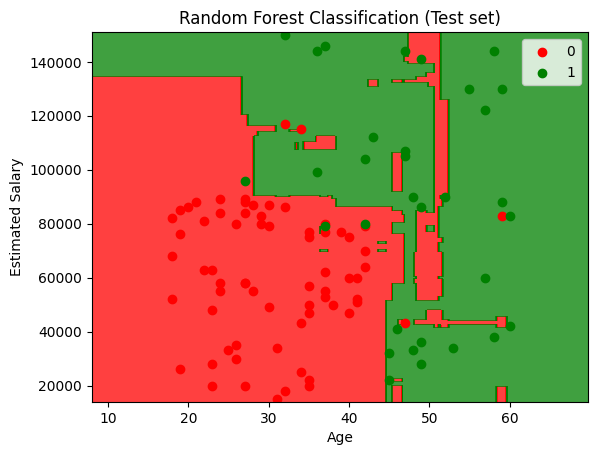

: 

In [ ]:
# Import color map utility for custom plot colors
from matplotlib.colors import ListedColormap

# Get back original values of test set (Age, Salary) for plotting
X_set, y_set = sc.inverse_transform(X_test), y_test

# Create a grid of points covering the feature space
X1, X2 = np.meshgrid(
    np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
    np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25)
)

# Predict class for each grid point and color regions accordingly
plt.contourf(
    X1, X2,
    classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
    alpha = 0.75, cmap = ListedColormap(('red', 'green'))
)

# Set plot limits
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# Plot actual test points on top of decision regions
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)

# Add title, axis labels, and legend
plt.title('Random Forest Classification (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()

# Show the plot
plt.show()